# Handcrafted Image Retrieval — v5 (Clean)
## Oxford & Paris Buildings

| Stage | Component | Source |
|-------|-----------|--------|
| 🔴 Offline | **RootSIFT** | Arandjelović & Zisserman (2012) |
| 🔴 Offline | **VLAD** | Jégou et al. (CVPR 2010) |
| 🔴 Offline | **PCA + Whitening** | Jégou & Chum (ECCV 2012) |
| 🔴 Offline | **SIFT cache** for RANSAC | — |
| 🟢 Online | Cosine similarity retrieval | Philbin et al. (CVPR 2007) |
| 🟢 Online | **RANSAC** spatial re-ranking | Philbin et al. (CVPR 2007) |
| 🟢 Online | **AQE** query expansion | Chum et al. (ICCV 2007) |

---
## Cell 1 — Imports

In [2]:
import os, sys, time, pickle, warnings, tarfile, urllib.request
warnings.filterwarnings('ignore')

import numpy as np
import cv2
from pathlib import Path
from tqdm.notebook import tqdm
from concurrent.futures import ThreadPoolExecutor, as_completed
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from sklearn.cluster import MiniBatchKMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import normalize

print(f'OpenCV : {cv2.__version__}')
print(f'NumPy  : {np.__version__}')

OpenCV : 4.13.0
NumPy  : 2.0.2


---
## Cell 2 — Configuration & GT Download

In [3]:
# ── Paths ─────────────────────────────────────────────────────────────────
DATASET_ROOT = Path('/kaggle/input/datasets/jeffreyamc/oxford-paris-buildings-v2')
OXFORD_IMGS  = DATASET_ROOT / 'oxford'
PARIS_IMGS   = DATASET_ROOT / 'paris'

OUTPUT_DIR   = Path('/kaggle/working/retrieval_output')
CACHE_DIR    = OUTPUT_DIR / 'cache'
GT_DIR       = OUTPUT_DIR / 'ground_truth'
SIFT_CACHE_DIR = CACHE_DIR / 'sift_kps'
for d in [OUTPUT_DIR, CACHE_DIR, GT_DIR, SIFT_CACHE_DIR]:
    d.mkdir(parents=True, exist_ok=True)

DATASETS_TO_USE = ['oxford', 'paris']

# ── Hyperparameters ───────────────────────────────────────────────────────
K_VLAD          = 256   # visual vocabulary size
PCA_DIM         = 512   # output dim after PCA+whitening (higher = more variance kept)
SIFT_N_FEATURES = 0     # 0 = no cap, OpenCV detects all ~3300 kps per image
MAX_IMAGE_SIZE  = 1024  # resize longest side to this before SIFT
N_WORKERS       = 4     # parallel CPU threads
RERANK_TOP_N    = 50    # RANSAC candidates per query
MIN_INLIERS     = 6     # min RANSAC inliers to confirm a match
AQE_TOP_K       = 10    # images used for query expansion
SIFT_RANSAC_KPS = 500   # max kps stored per image for RANSAC cache

# ── Landmark sets (those with official GT queries) ────────────────────────
OXFORD_GT_LANDMARKS = {
    'all_souls','ashmolean','balliol','bodleian','christ_church',
    'cornmarket','hertford','keble','magdalen','pitt_rivers','radcliffe_camera'
}
PARIS_GT_LANDMARKS = {
    'defense','eiffel','general','invalides','louvre','moulinrouge',
    'museedorsay','notredame','pantheon','pompidou','sacrecoeur','triomphe'
}

# ── GT Download ───────────────────────────────────────────────────────────
GT_URLS = {
    'oxford': 'https://www.robots.ox.ac.uk/~vgg/data/oxbuildings/gt_files_170407.tgz',
    'paris' : 'https://www.robots.ox.ac.uk/~vgg/data/parisbuildings/paris_120310.tgz',
}

def download_gt(dataset_name, url, gt_dir):
    marker = gt_dir / f'.{dataset_name}_downloaded'
    if marker.exists():
        print(f'[GT] {dataset_name} already downloaded')
        return
    tgz = gt_dir / f'{dataset_name}_gt.tgz'
    print(f'[GT] Downloading {dataset_name}...')
    urllib.request.urlretrieve(url, tgz)
    with tarfile.open(tgz) as t: t.extractall(gt_dir)
    tgz.unlink(); marker.touch()
    print(f'     Done')

for ds in DATASETS_TO_USE:
    download_gt(ds, GT_URLS[ds], GT_DIR)

print(f'GT query files total: {len(list(GT_DIR.rglob("*_query.txt")))}')

[GT] oxford already downloaded
[GT] paris already downloaded
GT query files total: 110


---
## Cell 3 — Dataset Scanner

In [4]:
def find_gt_flat(gt_root):
    """Find the flat directory containing *_query.txt files."""
    files = list(gt_root.rglob('*_query.txt'))
    return files[0].parent if files else None


def scan_dataset(img_root, gt_root, dataset_name, gt_landmarks):
    """
    Scan image folders and parse GT query files for one dataset.

    Image naming:
      Oxford images : all_souls_000013.jpg     (no prefix)
      Paris  images : paris_defense_000038.jpg (keep paris_ prefix)

    GT naming:
      Oxford GT : 'oxc1_all_souls_000013'  → strip 'oxc1_'
      Paris  GT : 'paris_defense_000038'   → keep as-is (matches filename)

    GT files in the flat directory contain BOTH Oxford and Paris.
    We filter by prefix:
      Oxford query files : do NOT start with 'paris_'
      Paris  query files : start with 'paris_'
    """
    img_paths, stem2path, queries = [], {}, []

    if not img_root.exists():
        print(f'[WARN] {img_root} not found'); return img_paths, stem2path, queries

    # ── Collect images ────────────────────────────────────────────────────
    lm_dirs = sorted(d for d in img_root.iterdir() if d.is_dir())
    n_dist  = 0
    print(f'\n{"="*55}\n  {dataset_name.upper()} — {len(lm_dirs)} folders\n{"="*55}')

    for lm in lm_dirs:
        is_gt = lm.name in gt_landmarks
        imgs  = sorted(lm.glob('*.jpg')) + sorted(lm.glob('*.JPG')) + sorted(lm.glob('*.png'))
        for p in imgs:
            img_paths.append(p)
            stem2path[p.stem] = p
        if not is_gt: n_dist += len(imgs)
        print(f'  [{"GT " if is_gt else "DIS"}]  {lm.name:22s}: {len(imgs):5d} imgs')

    # ── Parse GT query files ──────────────────────────────────────────────
    gt_flat = find_gt_flat(gt_root)
    if gt_flat is None:
        print('[WARN] No GT files found'); return img_paths, stem2path, queries

    # Filter by the image stem INSIDE each query file (not the filename):
    #   Oxford queries contain 'oxc1_...' → prefix = 'oxc1_'
    #   Paris  queries contain 'paris_...' → prefix = 'paris_'
    prefix = 'oxc1_' if dataset_name == 'oxford' else 'paris_'
    all_qfiles = sorted(gt_flat.glob('*_query.txt'))
    qfiles = []
    for qf in all_qfiles:
        with open(qf) as f:
            first_token = f.read().strip().split()[0]
        if first_token.startswith(prefix):
            qfiles.append(qf)

    def clean(s):
        s = s.strip()
        if dataset_name == 'oxford':
            s = s.replace('oxc1_', '').replace('oxf_', '')
        # Paris: keep paris_ prefix — it is part of the Kaggle filename
        return s

    def read_set(stem, sfx):
        p = gt_flat / f'{stem}_{sfx}.txt'
        if not p.exists(): return set()
        with open(p) as f: return {clean(l) for l in f if l.strip()}

    for qf in qfiles:
        q_stem = qf.stem.replace('_query', '')
        with open(qf) as f: parts = f.read().strip().split()
        queries.append({
            'name'      : f'{dataset_name}_{q_stem}',
            'dataset'   : dataset_name,
            'query_img' : clean(parts[0]),
            'query_roi' : list(map(float, parts[1:5])) if len(parts) >= 5 else None,
            'good'      : read_set(q_stem, 'good'),
            'ok'        : read_set(q_stem, 'ok'),
            'junk'      : read_set(q_stem, 'junk'),
        })

    print(f'  Total : {len(img_paths)} images  ({n_dist} distractors)')
    print(f'  Queries: {len(queries)}')
    if queries:
        q0 = queries[0]
        print(f'  Sample: {q0["name"]}  img={q0["query_img"]}  '
              f'good={len(q0["good"])}  ok={len(q0["ok"])}')
    return img_paths, stem2path, queries


ALL_IMG_PATHS, STEM2PATH, ALL_QUERIES = [], {}, []
if 'oxford' in DATASETS_TO_USE:
    a, b, c = scan_dataset(OXFORD_IMGS, GT_DIR, 'oxford', OXFORD_GT_LANDMARKS)
    ALL_IMG_PATHS += a; STEM2PATH.update(b); ALL_QUERIES += c
if 'paris' in DATASETS_TO_USE:
    a, b, c = scan_dataset(PARIS_IMGS,  GT_DIR, 'paris',  PARIS_GT_LANDMARKS)
    ALL_IMG_PATHS += a; STEM2PATH.update(b); ALL_QUERIES += c

N_IMAGES       = len(ALL_IMG_PATHS)
DB_STEMS       = [p.stem for p in ALL_IMG_PATHS]
STEM_TO_IDX    = {s: i for i, s in enumerate(DB_STEMS)}
oxford_queries = [q for q in ALL_QUERIES if q['dataset'] == 'oxford']
paris_queries  = [q for q in ALL_QUERIES if q['dataset'] == 'paris']

print(f'\nDB={N_IMAGES}  Oxford_q={len(oxford_queries)}  Paris_q={len(paris_queries)}')
assert len(oxford_queries) == 55, f'Expected 55 Oxford queries, got {len(oxford_queries)}'
assert len(paris_queries)  == 55, f'Expected 55 Paris  queries, got {len(paris_queries)}'
print('✅ Query counts correct')


  OXFORD — 17 folders
  [GT ]  all_souls             :   132 imgs
  [GT ]  ashmolean             :   195 imgs
  [GT ]  balliol               :   154 imgs
  [GT ]  bodleian              :   214 imgs
  [GT ]  christ_church         :   543 imgs
  [GT ]  cornmarket            :    59 imgs
  [GT ]  hertford              :    67 imgs
  [DIS]  jesus                 :   161 imgs
  [GT ]  keble                 :   121 imgs
  [GT ]  magdalen              :   685 imgs
  [DIS]  new                   :   458 imgs
  [DIS]  oriel                 :    95 imgs
  [DIS]  oxford                :  1502 imgs
  [GT ]  pitt_rivers           :   108 imgs
  [GT ]  radcliffe_camera      :   282 imgs
  [DIS]  trinity               :   217 imgs
  [DIS]  worcester             :    70 imgs
  Total : 5063 images  (2503 distractors)
  Queries: 55
  Sample: oxford_all_souls_1  img=all_souls_000013  good=24  ok=54

  PARIS — 12 folders
  [GT ]  defense               :   381 imgs
  [GT ]  eiffel                :   147 i

---
# 🔴 OFFLINE STAGE
## Offline Step 1 — RootSIFT
> **Arandjelović & Zisserman (2012)**  
> L1-normalize SIFT → element-wise √. Euclidean on RootSIFT ≡ Hellinger kernel on SIFT.

In [7]:
def compute_rootsift(descs):
    descs = descs.astype(np.float32)
    descs /= (descs.sum(axis=1, keepdims=True) + 1e-7)  # L1 normalize
    return np.sqrt(descs)                                 # element-wise sqrt


def extract_rootsift(image_path, roi=None,
                     max_size=MAX_IMAGE_SIZE, n_features=SIFT_N_FEATURES):
    """
    Extract RootSIFT descriptors from an image.
    roi=[x1,y1,x2,y2]: keep only keypoints inside this region (for query images).
    """
    try:
        img = cv2.imread(str(image_path), cv2.IMREAD_GRAYSCALE)
        if img is None: return [], None
        h, w  = img.shape
        scale = min(max_size / max(h, w), 1.0)
        if scale < 1.0:
            img = cv2.resize(img, (int(w*scale), int(h*scale)), interpolation=cv2.INTER_AREA)
        sift = cv2.SIFT_create(nfeatures=n_features, contrastThreshold=0.04, edgeThreshold=10)
        kps, descs = sift.detectAndCompute(img, None)
        if descs is None or len(descs) == 0: return [], None
        descs = compute_rootsift(descs)
        if roi is not None:
            x1, y1, x2, y2 = [c*scale for c in roi]
            mask  = np.array([x1<=kp.pt[0]<=x2 and y1<=kp.pt[1]<=y2 for kp in kps], dtype=bool)
            kps   = [kp for kp, m in zip(kps, mask) if m]
            descs = descs[mask] if mask.any() else None
            if descs is None or len(descs) == 0: return [], None
        return kps, descs
    except Exception as e:
        return [], None


# Sanity check
kps, d = extract_rootsift(ALL_IMG_PATHS[0])
print(f'RootSIFT OK: {len(kps)} kps, norm={np.linalg.norm(d[0]):.4f}')

RootSIFT OK: 5260 kps, norm=1.0000


## Offline Step 2 — Visual Vocabulary (K-Means)

In [8]:
VOCAB_CACHE = CACHE_DIR / f'vocab_K{K_VLAD}.pkl'

def build_vocabulary(image_paths, k=K_VLAD, max_per_img=150,
                     n_sample=2000, cache_path=None):
    """
    Build visual vocabulary with MiniBatchKMeans.
    Fast path: load descriptors from SIFT cache if available.
    Slow path: extract SIFT live.
    """
    if cache_path and cache_path.exists():
        print(f'[CACHE] Vocabulary ← {cache_path.name}')
        with open(cache_path, 'rb') as f: return pickle.load(f)

    rng  = np.random.default_rng(42)
    idxs = rng.choice(len(image_paths), min(n_sample, len(image_paths)), replace=False)

    n_cached = len(list(SIFT_CACHE_DIR.glob('*.npz')))
    use_cache = n_cached >= len(image_paths) * 0.9
    print(f'Building K={k} vocabulary [{"from SIFT cache" if use_cache else "live extraction"}]...')
    t0 = time.time()

    all_descs = []
    if use_cache:
        for i in tqdm(idxs, desc='Loading descriptors'):
            npz = SIFT_CACHE_DIR / f'{image_paths[i].stem}.npz'
            if not npz.exists(): continue
            d = np.load(npz)['descs']
            if len(d) == 0: continue
            if len(d) > max_per_img:
                d = d[np.random.choice(len(d), max_per_img, replace=False)]
            all_descs.append(d)
    else:
        for i in tqdm(idxs, desc='Extracting SIFT'):
            _, d = extract_rootsift(image_paths[i])
            if d is not None and len(d) > 0:
                if len(d) > max_per_img:
                    d = d[np.random.choice(len(d), max_per_img, replace=False)]
                all_descs.append(d)

    if not all_descs:
        raise RuntimeError('No descriptors — check image paths or SIFT cache')

    X  = np.vstack(all_descs).astype(np.float32)
    print(f'  Clustering {len(X):,} descriptors → {k} words...')
    km = MiniBatchKMeans(n_clusters=k, random_state=42,
                         batch_size=min(20_000, len(X)),
                         max_iter=300, n_init=5, verbose=0)
    km.fit(X)
    print(f'  Done in {time.time()-t0:.1f}s')
    if cache_path:
        with open(cache_path, 'wb') as f: pickle.dump(km, f)
        print(f'  Cached → {cache_path.name}')
    return km


VOCABULARY = build_vocabulary(ALL_IMG_PATHS, k=K_VLAD, cache_path=VOCAB_CACHE)
CENTROIDS  = VOCABULARY.cluster_centers_.astype(np.float32)
print(f'Centroids: {CENTROIDS.shape}')

[CACHE] Vocabulary ← vocab_K256.pkl
Centroids: (256, 128)


## Offline Step 3 — VLAD Encoding
> **Jégou et al. (CVPR 2010)** — residual accumulation + power norm + L2 normalize.

In [9]:
def vlad_encode(descs, centroids, power_norm=True):
    """
    Encode descriptors as VLAD vector.
    1. Assign each descriptor to nearest centroid (numpy, no FAISS needed)
    2. Accumulate residuals per centroid
    3. Power normalization (signed sqrt) — reduces burstiness
    4. L2 normalize
    """
    K, D   = centroids.shape
    descs  = descs.astype(np.float32)
    # Fast assignment: ||x-c||^2 = ||x||^2 - 2x·c + ||c||^2
    x_sq   = (descs**2).sum(1, keepdims=True)
    c_sq   = (centroids**2).sum(1, keepdims=True).T
    assign = np.argmin(x_sq + c_sq - 2.0*(descs @ centroids.T), axis=1)
    vlad   = np.zeros((K, D), dtype=np.float32)
    np.add.at(vlad, assign, descs - centroids[assign])
    if power_norm:
        vlad = np.sign(vlad) * np.sqrt(np.abs(vlad))
    vlad = vlad.flatten()
    n    = np.linalg.norm(vlad)
    return vlad / n if n > 1e-8 else vlad


v = vlad_encode(d, CENTROIDS)
print(f'VLAD shape: {v.shape}  norm={np.linalg.norm(v):.4f}')

VLAD shape: (32768,)  norm=1.0000


## Offline Step 4 — Extract VLAD for ALL Database Images

All images enter the index — landmarks **and** distractors.
Distractors are automatically negative: if ranked high they lower the AP.

In [12]:
VLAD_RAW_CACHE = CACHE_DIR / f'vlad_raw_K{K_VLAD}.npy'
STEMS_CACHE    = CACHE_DIR / 'db_stems.pkl'

def build_database(image_paths, centroids, cache_vlad=None, cache_stems=None):
    if cache_vlad and cache_vlad.exists() and cache_stems and cache_stems.exists():
        print(f'[CACHE] DB ← {cache_vlad.name}')
        mat = np.load(cache_vlad)
        with open(cache_stems, 'rb') as f: stems = pickle.load(f)
        print(f'  {len(stems)} vectors, dim={mat.shape[1]}')
        return mat, stems

    print(f'[OFFLINE] Extracting VLAD for {len(image_paths)} images...')
    t0   = time.time()
    dim  = len(centroids) * 128
    mat  = np.zeros((len(image_paths), dim), dtype=np.float32)
    stms = [''] * len(image_paths)

    print('  Phase 1: parallel SIFT extraction (CPU)...')
    raw = [None] * len(image_paths)

    def sift_worker(args):
        idx, path = args
        _, descs = extract_rootsift(path)
        return idx, path.stem, descs

    with ThreadPoolExecutor(max_workers=N_WORKERS) as ex:
        futs = {ex.submit(sift_worker, (i, p)): i for i, p in enumerate(image_paths)}
        for fut in tqdm(as_completed(futs), total=len(futs), desc='SIFT'):
            try:
                idx, stem, descs = fut.result()
                raw[idx] = (stem, descs)
            except Exception: pass

    print('  Phase 2: VLAD encoding...')
    for idx, item in enumerate(tqdm(raw, desc='VLAD')):
        if item is None: continue
        stem, descs = item
        stms[idx] = stem
        if descs is not None and len(descs) > 0:
            mat[idx] = vlad_encode(descs, centroids)

    print(f'  Done in {time.time()-t0:.1f}s')
    if cache_vlad:
        np.save(cache_vlad, mat)
        with open(cache_stems, 'wb') as f: pickle.dump(stms, f)
        print(f'  Cached → {cache_vlad.name}')
    return mat, stms


VLAD_RAW, DB_STEMS = build_database(
    ALL_IMG_PATHS, CENTROIDS,
    cache_vlad=VLAD_RAW_CACHE, cache_stems=STEMS_CACHE)
STEM_TO_IDX = {s: i for i, s in enumerate(DB_STEMS)}
print(f'VLAD_RAW: {VLAD_RAW.shape}')

[CACHE] DB ← vlad_raw_K256.npy
  11475 vectors, dim=32768
VLAD_RAW: (11475, 32768)


## Offline Step 4.5 — Pre-compute SIFT Cache for RANSAC

RANSAC needs keypoint positions not stored in VLAD.
Caching avoids re-extracting SIFT at query time: 0.002s/img vs 0.4s/img.

In [10]:
SIFT_CACHE_MARKER = CACHE_DIR / '.sift_cache_done'

def precompute_sift_cache(image_paths, max_kps=SIFT_RANSAC_KPS):
    """
    Save top-max_kps keypoints per image to sift_kps/<stem>.npz.
    Keeps only strongest keypoints (by SIFT response) to cap disk usage.
    Full 3300 kps × 11475 imgs = 19.7 GB; 500 kps = ~3 GB.
    """
    if SIFT_CACHE_MARKER.exists():
        n = len(list(SIFT_CACHE_DIR.glob('*.npz')))
        print(f'[CACHE] SIFT cache already built ({n} files)')
        return

    print(f'[OFFLINE] Pre-computing SIFT cache ({max_kps} kps/img)...')
    t0 = time.time()

    def worker(path):
        out = SIFT_CACHE_DIR / f'{path.stem}.npz'
        if out.exists(): return
        kps, descs = extract_rootsift(path)
        if descs is None or len(descs) == 0:
            np.savez_compressed(out,
                pts=np.zeros((0,2), dtype=np.float32),
                descs=np.zeros((0,128), dtype=np.float32))
            return
        if len(kps) > max_kps:
            responses = np.array([kp.response for kp in kps])
            top = np.argsort(-responses)[:max_kps]
            kps, descs = [kps[i] for i in top], descs[top]
        pts = np.array([kp.pt for kp in kps], dtype=np.float32)
        np.savez_compressed(out, pts=pts, descs=descs)

    with ThreadPoolExecutor(max_workers=N_WORKERS) as ex:
        list(tqdm(ex.map(worker, image_paths), total=len(image_paths), desc='SIFT cache'))

    SIFT_CACHE_MARKER.touch()
    mb = sum(f.stat().st_size for f in SIFT_CACHE_DIR.glob('*.npz')) / 1e6
    print(f'  Done in {time.time()-t0:.0f}s  |  {mb:.0f} MB on disk')


def load_sift_cached(stem):
    """Load pre-computed SIFT from disk. ~0.002s vs ~0.4s for live extraction."""
    p = SIFT_CACHE_DIR / f'{stem}.npz'
    if not p.exists(): return None, None
    data = np.load(p)
    pts, descs = data['pts'], data['descs']
    return (pts, descs) if len(pts) > 0 else (None, None)


precompute_sift_cache(ALL_IMG_PATHS)

[CACHE] SIFT cache already built (11475 files)


## Offline Step 5 — PCA + Whitening
> **Jégou & Chum (ECCV 2012)**  
> Mean subtraction → handles co-missing visual words.  
> Eigenvalue scaling → handles co-occurrences.  
> L2 re-normalize after projection.

In [13]:
PCA_CACHE  = CACHE_DIR / f'pca_K{K_VLAD}_D{PCA_DIM}.pkl'
DBIDX_PATH = CACHE_DIR / f'db_index_K{K_VLAD}_D{PCA_DIM}.npy'

def fit_pca_whitening(vlad_matrix, n_components=PCA_DIM, cache_path=None):
    if cache_path and cache_path.exists():
        print(f'[CACHE] PCA ← {cache_path.name}')
        with open(cache_path, 'rb') as f: return pickle.load(f)
    print(f'[OFFLINE] PCA (n={n_components}, whiten=True)...')
    t0  = time.time()
    pca = PCA(n_components=n_components, whiten=True, random_state=42)
    pca.fit(vlad_matrix)
    print(f'  Variance explained: {pca.explained_variance_ratio_.sum()*100:.1f}%  ({time.time()-t0:.1f}s)')
    if cache_path:
        with open(cache_path, 'wb') as f: pickle.dump(pca, f)
        print(f'  Cached → {cache_path.name}')
    return pca


def apply_pca_whitening(vlad_matrix, pca):
    """Project + whiten + L2 re-normalize (critical step from Jégou & Chum)."""
    proj = pca.transform(vlad_matrix)
    return normalize(proj, norm='l2').astype(np.float32)


PCA_MODEL = fit_pca_whitening(VLAD_RAW, n_components=PCA_DIM, cache_path=PCA_CACHE)

if DBIDX_PATH.exists():
    print(f'[CACHE] DB index ← {DBIDX_PATH.name}')
    DB_VLAD = np.load(DBIDX_PATH)
else:
    print('[OFFLINE] Projecting DB...')
    DB_VLAD = apply_pca_whitening(VLAD_RAW, PCA_MODEL)
    np.save(DBIDX_PATH, DB_VLAD)

print(f'DB index: {DB_VLAD.shape}  norm_mean={np.linalg.norm(DB_VLAD, axis=1).mean():.4f}')
print('\n✅  OFFLINE STAGE COMPLETE')

[CACHE] PCA ← pca_K256_D512.pkl
[CACHE] DB index ← db_index_K256_D512.npy
DB index: (11475, 512)  norm_mean=1.0000

✅  OFFLINE STAGE COMPLETE


---
# 🟢 ONLINE STAGE

In [5]:
def encode_query(image_path, roi=None):
    """RootSIFT (inside ROI) → VLAD → PCA+whiten → L2 norm."""
    _, descs = extract_rootsift(image_path, roi=roi)
    if descs is None or len(descs) == 0:
        return np.zeros(PCA_DIM, dtype=np.float32)
    vlad = vlad_encode(descs, CENTROIDS)
    return apply_pca_whitening(vlad[np.newaxis], PCA_MODEL)[0]


def initial_retrieve(query_vec, exclude=None):
    """Cosine similarity = dot product on L2-normalized vectors."""
    sims   = DB_VLAD @ query_vec
    idx    = np.argsort(-sims)
    stems  = [DB_STEMS[i] for i in idx]
    scores = sims[idx]
    if exclude:
        mask   = [s != exclude for s in stems]
        stems  = [s for s, m in zip(stems, mask) if m]
        scores = scores[np.array(mask)]
    return stems, scores


def ransac_rerank(query_path, query_roi, ranked_stems,
                  top_n=RERANK_TOP_N, min_inliers=MIN_INLIERS):
    """
    Re-rank top-N candidates using RANSAC homography verification.
    Loads SIFT from disk cache (~0.002s/img) instead of re-extracting (~0.4s/img).
    """
    to_rerank = ranked_stems[:top_n]
    rest      = ranked_stems[top_n:]

    # Query SIFT: try cache first, fallback to live extraction
    q_pts, q_descs = load_sift_cached(query_path.stem)
    if q_descs is None:
        q_kps, q_descs = extract_rootsift(query_path, roi=query_roi)
        if q_descs is None or len(q_kps) < 4: return ranked_stems
        q_pts = np.float32([kp.pt for kp in q_kps])
    q_pts = q_pts.astype(np.float32)

    # Load all candidate SIFT from disk in parallel
    def load_cand(stem):
        pts, descs = load_sift_cached(stem)
        if pts is None:
            path = STEM2PATH.get(stem)
            if path is None: return stem, None, None
            kps, descs = extract_rootsift(path)
            pts = np.float32([kp.pt for kp in kps]) if kps else None
        return stem, pts, descs

    cand_data = {}
    with ThreadPoolExecutor(max_workers=N_WORKERS) as ex:
        for stem, pts, descs in ex.map(load_cand, to_rerank):
            cand_data[stem] = (pts, descs)

    # RANSAC verification (single-threaded — cv2 not thread-safe)
    flann   = cv2.FlannBasedMatcher(dict(algorithm=1, trees=5), dict(checks=50))
    inliers = {}
    for stem in to_rerank:
        c_pts, c_descs = cand_data.get(stem, (None, None))
        if c_descs is None or len(c_pts) < 4: inliers[stem] = 0; continue
        c_pts = c_pts.astype(np.float32)
        try:
            matches = flann.knnMatch(q_descs, c_descs, k=2)
            good    = [m for p in matches if len(p)==2
                       for m, n in [p] if m.distance < 0.75*n.distance]
            if len(good) < 4: inliers[stem] = 0; continue
            src = np.float32([q_pts[m.queryIdx] for m in good]).reshape(-1,1,2)
            dst = np.float32([c_pts[m.trainIdx] for m in good]).reshape(-1,1,2)
            _, mask = cv2.findHomography(src, dst, cv2.RANSAC, ransacReprojThreshold=10.0)
            inliers[stem] = int(mask.sum()) if mask is not None else 0
        except Exception: inliers[stem] = 0

    def key(s):
        c = inliers.get(s, 0)
        return (0 if c >= min_inliers else 1, -c)
    return sorted(to_rerank, key=key) + list(rest)


def average_query_expansion(query_vec, ranked_stems, top_k=AQE_TOP_K):
    """Average query with top-k DB vectors, then L2-renormalize."""
    vecs = [query_vec]
    for stem in ranked_stems[:top_k]:
        idx = STEM_TO_IDX.get(stem)
        if idx is not None: vecs.append(DB_VLAD[idx])
    if len(vecs) == 1: return query_vec
    exp = np.mean(vecs, axis=0).astype(np.float32)
    n   = np.linalg.norm(exp)
    return exp / n if n > 1e-8 else exp


def _ap(ranked, good, ok, junk):
    """
    Oxford/Paris AP — exact translation of the official compute_ap.cpp
    Uses trapezoidal integration over the precision-recall curve.
    """
    pos = good | ok
    if not pos: return 0.0

    old_recall    = 0.0
    old_precision = 1.0
    ap = 0.0
    intersect = 0
    j = 0   # counts non-junk items seen

    for s in ranked:
        if s in junk:
            continue        # skip junk — don't increment j
        if s in pos:
            intersect += 1

        recall    = intersect / len(pos)
        precision = intersect / (j + 1.0)

        # Trapezoidal area between previous and current point
        ap += (recall - old_recall) * ((old_precision + precision) / 2.0)

        old_recall    = recall
        old_precision = precision
        j += 1

    return ap


def _pk(ranked, good, ok, junk, k=5):
    pos = good | ok; n_seen = n_rel = 0
    for s in ranked:
        if s in junk: continue
        n_seen += 1
        if s in pos: n_rel += 1
        if n_seen == k: break
    return n_rel/k if k else 0.0


def run_query(query_info, use_ransac=True, use_aqe=True):
    q_path = STEM2PATH.get(query_info['query_img'])
    if q_path is None: return [], 0.0, 0.0
    q_roi = query_info['query_roi']
    good, ok, junk = query_info['good'], query_info['ok'], query_info['junk']

    q_vec          = encode_query(q_path, roi=q_roi)
    ranked, scores = initial_retrieve(q_vec, exclude=query_info['query_img'])
    if use_ransac:
        ranked = ransac_rerank(q_path, q_roi, ranked)
    if use_aqe:
        exp_q  = average_query_expansion(q_vec, ranked)
        ranked, _ = initial_retrieve(exp_q, exclude=query_info['query_img'])
    return ranked, _ap(ranked, good, ok, junk), _pk(ranked, good, ok, junk)


print('Online pipeline ready.')

Online pipeline ready.


---
# 📊 EVALUATION — Baseline & Full Pipeline

In [14]:
def evaluate(queries, use_ransac=True, use_aqe=True, tag=''):
    all_ap, all_p5, results = [], [], {}
    for q in tqdm(queries, desc=tag or 'Eval'):
        ranked, ap, p5 = run_query(q, use_ransac, use_aqe)
        all_ap.append(ap); all_p5.append(p5)
        results[q['name']] = {'ranked': ranked, 'ap': ap, 'p5': p5, 'query_info': q}
    mAP = float(np.mean(all_ap)); mP5 = float(np.mean(all_p5))
    print(f'  {tag:45s} mAP={mAP:.4f}  P@5={mP5:.4f}')
    return mAP, mP5, results


print('='*55, '\nBASELINE (VLAD + PCA-Whitening only)\n' + '='*55)
mAP_ox_b = mAP_pa_b = 0.0; res_ox_b = res_pa_b = {}
if oxford_queries: mAP_ox_b, _, res_ox_b = evaluate(oxford_queries, False, False, 'Oxford-Baseline')
if paris_queries:  mAP_pa_b, _, res_pa_b = evaluate(paris_queries,  False, False, 'Paris-Baseline')

BASELINE (VLAD + PCA-Whitening only)


Oxford-Baseline:   0%|          | 0/55 [00:00<?, ?it/s]

  Oxford-Baseline                               mAP=0.3549  P@5=0.7600


Paris-Baseline:   0%|          | 0/55 [00:00<?, ?it/s]

  Paris-Baseline                                mAP=0.4310  P@5=0.9927


In [15]:
print('='*55, '\nFULL PIPELINE (RANSAC + AQE)\n' + '='*55)
mAP_ox_f = mAP_pa_f = 0.0; res_ox_f = res_pa_f = {}
if oxford_queries: mAP_ox_f, _, res_ox_f = evaluate(oxford_queries, True, True, 'Oxford-Full')
if paris_queries:  mAP_pa_f, _, res_pa_f = evaluate(paris_queries,  True, True, 'Paris-Full')

FULL PIPELINE (RANSAC + AQE)


Oxford-Full:   0%|          | 0/55 [00:00<?, ?it/s]

  Oxford-Full                                   mAP=0.4810  P@5=0.7745


Paris-Full:   0%|          | 0/55 [00:00<?, ?it/s]

  Paris-Full                                    mAP=0.6145  P@5=0.9927


---
# 📊 ABLATION STUDY — Oxford & Paris separately

For each dataset, compare the contribution of each pipeline component:
- Baseline: VLAD + PCA-Whitening only
- + RANSAC: adds geometric verification
- + AQE: adds query expansion
- Full: RANSAC + AQE combined

In [16]:
ablation_configs = [
    ('Baseline (VLAD+PCA-Wh)', False, False),
    ('+ RANSAC only',          True,  False),
    ('+ AQE only',             False, True),
    ('+ RANSAC + AQE (Full)',  True,  True),
]

ablation_oxford = {}
ablation_paris  = {}

if oxford_queries:
    print('\n── ABLATION: OXFORD ─────────────────────────────────────')
    for label, r, a in ablation_configs:
        v, _, _ = evaluate(oxford_queries, r, a, f'Oxford | {label}')
        ablation_oxford[label] = v

if paris_queries:
    print('\n── ABLATION: PARIS ──────────────────────────────────────')
    for label, r, a in ablation_configs:
        v, _, _ = evaluate(paris_queries, r, a, f'Paris  | {label}')
        ablation_paris[label] = v

# Print side-by-side comparison
print(f'\n{"Component":35s}  {"Oxford":>8}  {"Paris":>8}')
print('-' * 55)
for label in ablation_configs:
    l = label[0]
    ox = ablation_oxford.get(l, 0.0)
    pa = ablation_paris.get(l, 0.0)
    print(f'{l:35s}  {ox:8.4f}  {pa:8.4f}')


── ABLATION: OXFORD ─────────────────────────────────────


Oxford | Baseline (VLAD+PCA-Wh):   0%|          | 0/55 [00:00<?, ?it/s]

  Oxford | Baseline (VLAD+PCA-Wh)               mAP=0.3549  P@5=0.7600


Oxford | + RANSAC only:   0%|          | 0/55 [00:00<?, ?it/s]

  Oxford | + RANSAC only                        mAP=0.3285  P@5=0.7127


...

  Paris  | + RANSAC only                        mAP=0.4320  P@5=0.9891


Paris  | + AQE only:   0%|          | 0/55 [00:00<?, ?it/s]

  Paris  | + AQE only                           mAP=0.5955  P@5=0.9964


Paris  | + RANSAC + AQE (Full):   0%|          | 0/55 [00:00<?, ?it/s]

  Paris  | + RANSAC + AQE (Full)                mAP=0.6168  P@5=0.9964

Component                              Oxford     Paris
-------------------------------------------------------
Baseline (VLAD+PCA-Wh)                 0.3549    0.4310
+ RANSAC only                          0.3285    0.4320
+ AQE only                             0.4591    0.5955
+ RANSAC + AQE (Full)                  0.4726    0.6168


---
# 🖼️ QUALITATIVE EVALUATION — Top-5 Results

In [17]:
from pathlib import Path

paris_root = Path('/kaggle/input/datasets/jeffreyamc/oxford-paris-buildings-v2/paris')
all_paris  = {p.stem for p in paris_root.rglob('*.jpg')}

# Cuántos stems del GT de Paris existen realmente en el dataset
from pathlib import Path
gt_flat = list(Path('/kaggle/working/retrieval_output/ground_truth').rglob('*_good.txt'))[0].parent

paris_gt_stems = set()
for f in gt_flat.glob('*.txt'):
    with open(f) as fh:
        for line in fh:
            s = line.strip()
            if s.startswith('paris_'):
                paris_gt_stems.add(s)

found   = paris_gt_stems & all_paris
missing = paris_gt_stems - all_paris

print(f'GT references {len(paris_gt_stems)} Paris stems')
print(f'Found in dataset : {len(found)}')
print(f'Missing          : {len(missing)}')
print(f'Coverage         : {100*len(found)/max(len(paris_gt_stems),1):.1f}%')

GT references 3454 Paris stems
Found in dataset : 3399
Missing          : 55
Coverage         : 98.4%


In [18]:
from pathlib import Path

oxford_root = Path('/kaggle/input/datasets/jeffreyamc/oxford-paris-buildings-v2/oxford')
all_oxford  = {p.stem for p in oxford_root.rglob('*.jpg')}

gt_flat = list(Path('/kaggle/working/retrieval_output/ground_truth').rglob('*_good.txt'))[0].parent

oxford_gt_stems = set()
for f in gt_flat.glob('*.txt'):
    with open(f) as fh:
        for line in fh:
            s = line.strip().replace('oxc1_', '').replace('oxf_', '')
            if s and not s.startswith('paris_'):
                oxford_gt_stems.add(s)

found   = oxford_gt_stems & all_oxford
missing = oxford_gt_stems - all_oxford

print(f'GT references {len(oxford_gt_stems)} Oxford stems')
print(f'Found in dataset : {len(found)}')
print(f'Missing          : {len(missing)}')
print(f'Coverage         : {100*len(found)/max(len(oxford_gt_stems),1):.1f}%')
print()
if missing:
    print(f'Sample missing stems:')
    for s in sorted(missing)[:10]:
        print(f'  {s}')

GT references 900 Oxford stems
Found in dataset : 845
Missing          : 55
Coverage         : 93.9%

Sample missing stems:
  all_souls_000013 136.5 34.1 648.5 955.7
  all_souls_000026 78 5 714 1000
  all_souls_000051 430 120 643 470
  ashmolean_000000 287 0 735 218
  ashmolean_000007 18 49 761 416
  ashmolean_000058 187.7 17.1 887.5 238.9
  ashmolean_000269 543 56 994 438
  ashmolean_000305 364 169 697 391
  balliol_000051 6.8 34.1 682.6 716.8
  balliol_000167 441 37 931 737


In [ ]:
# Los 55 faltantes de Paris — ¿son las query images?
missing_paris = paris_gt_stems - all_paris
query_imgs_paris = {q['query_img'] for q in paris_queries}

overlap = missing_paris & query_imgs_paris
print(f'Missing Paris stems that are query images: {len(overlap)}/{len(missing_paris)}')
print(f'Sample: {sorted(overlap)[:5]}')


── Oxford BEST — AP=0.833 ──


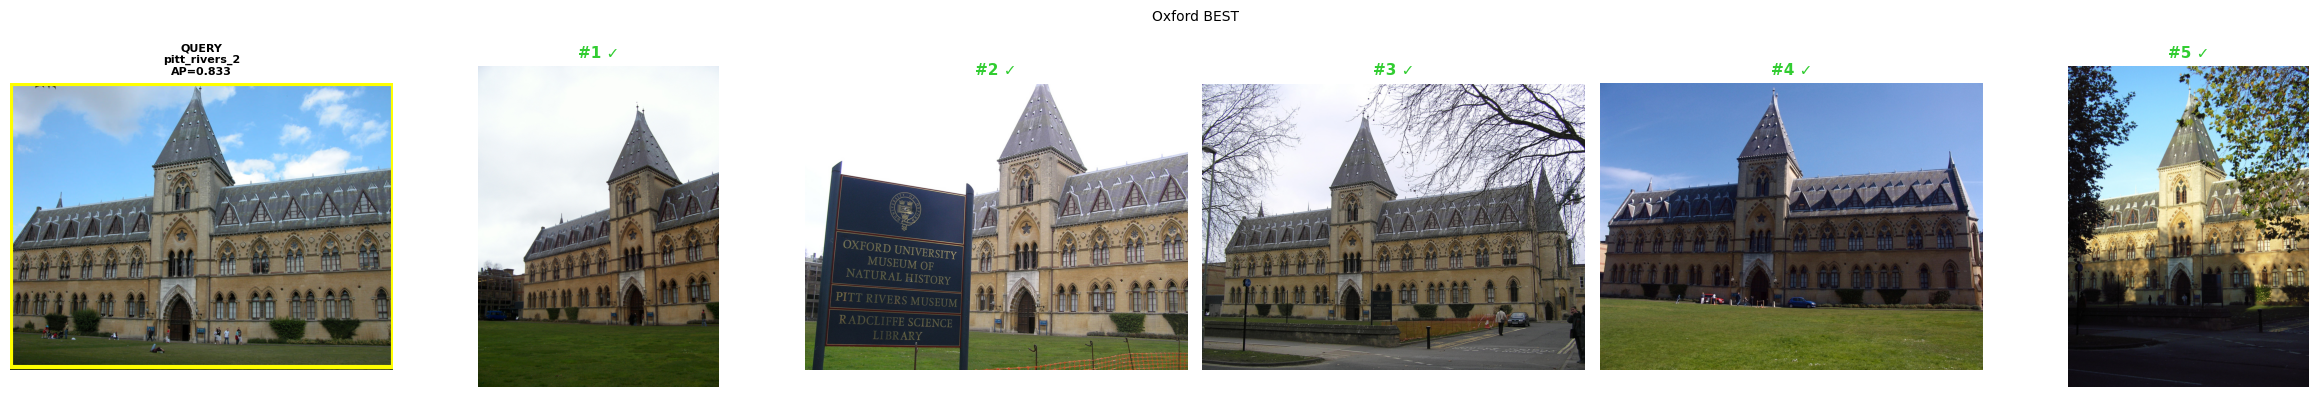


── Oxford MEDIAN — AP=0.551 ──


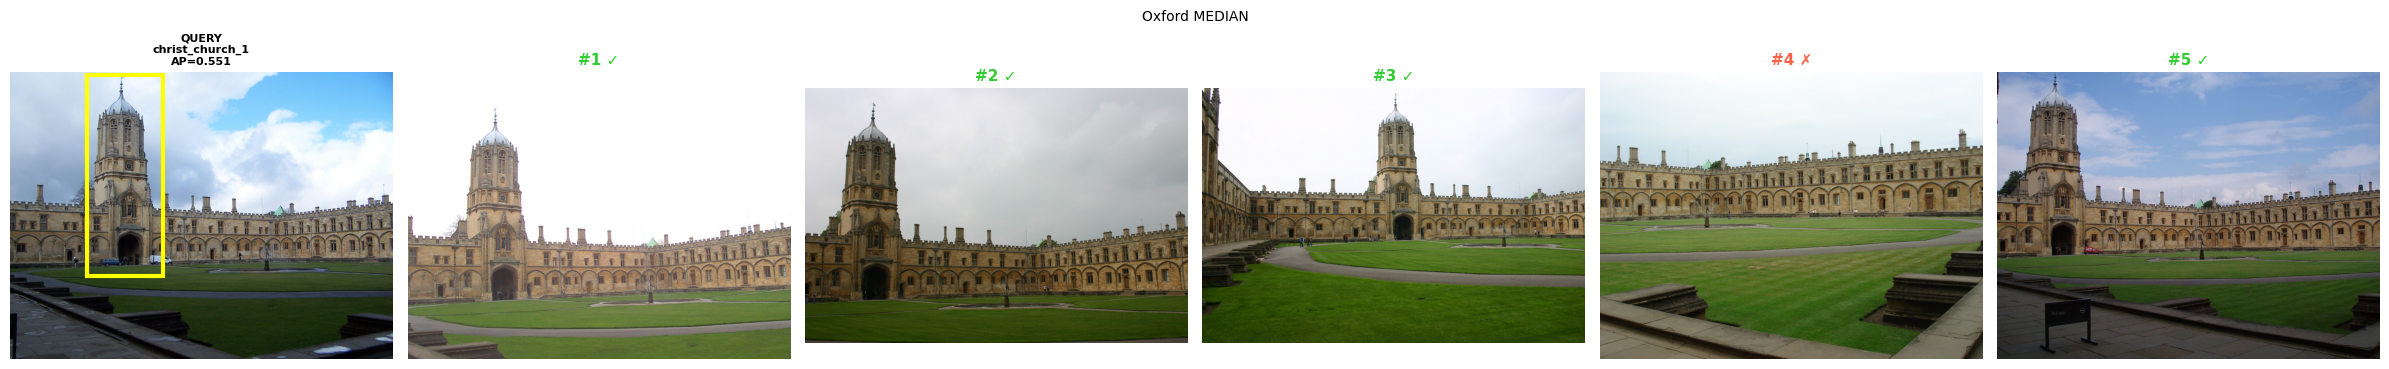


── Oxford WORST — AP=0.004 ──


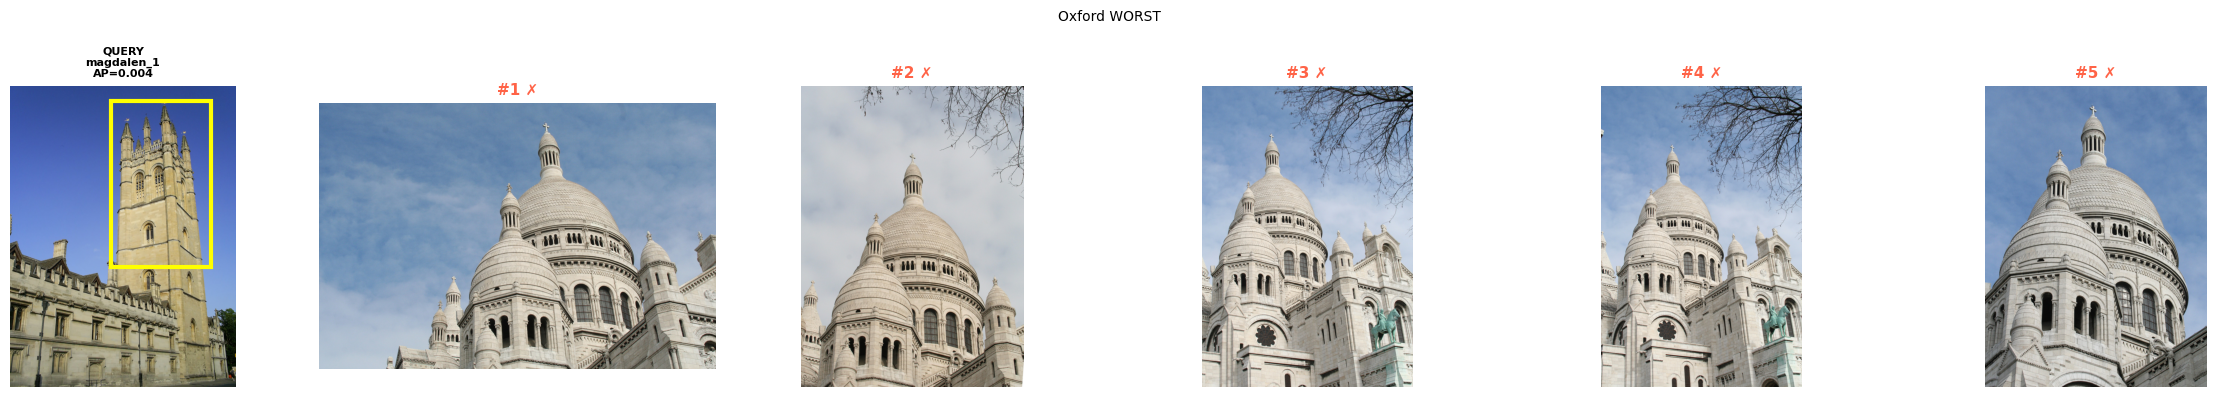


── Paris BEST — AP=0.934 ──


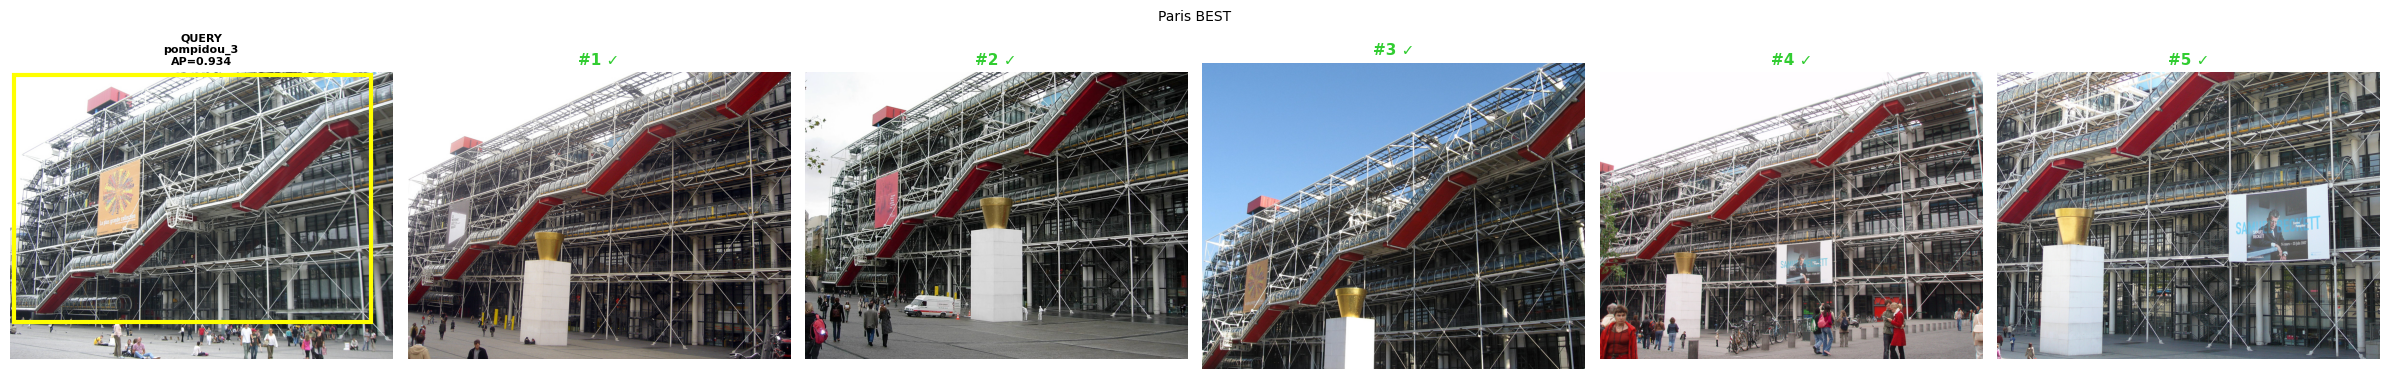


── Paris MEDIAN — AP=0.583 ──


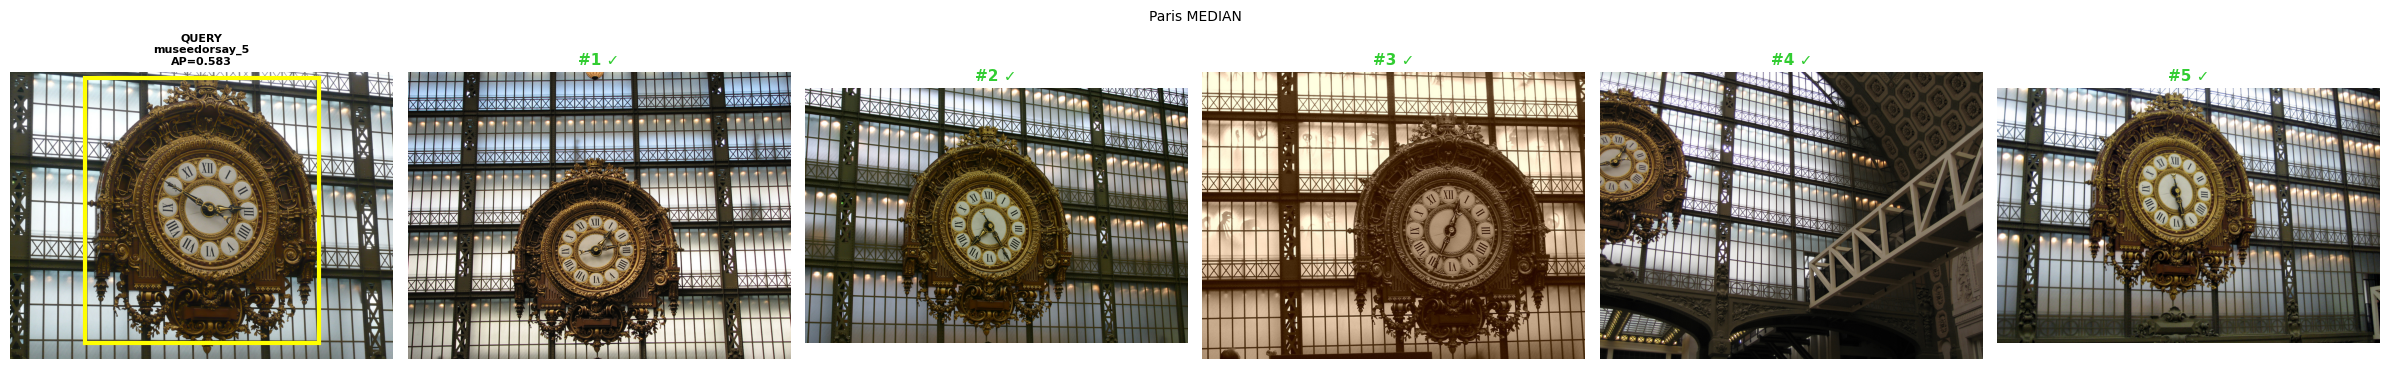


── Paris WORST — AP=0.258 ──


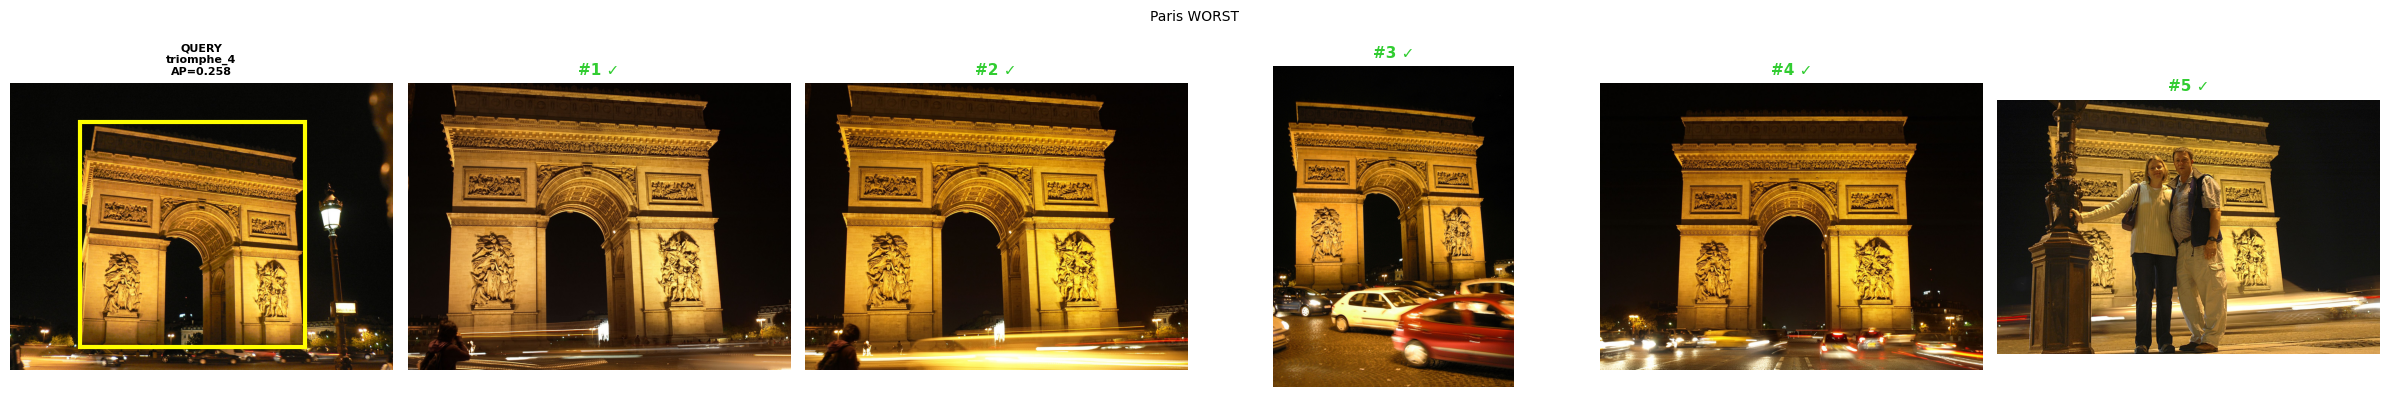

In [17]:
def show_top5(query_info, ranked_stems, n_show=5, title_prefix=''):
    pos  = query_info['good'] | query_info['ok']
    junk = query_info['junk']
    top5 = [s for s in ranked_stems if s not in junk][:n_show]
    fig, axes = plt.subplots(1, n_show+1, figsize=(4*(n_show+1), 4))
    qname = query_info['name'].replace('oxford_','').replace('paris_','')
    ap    = f"{_ap(ranked_stems, pos, set(), junk):.3f}"

    def load(stem):
        p = STEM2PATH.get(stem)
        if p is None:
            return np.zeros((200, 200, 3), dtype=np.uint8)
        
        # Try cv2 first
        img = cv2.imread(str(p), cv2.IMREAD_COLOR)
        if img is not None:
            return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        
        # Fallback: PIL (handles more formats and filesystem quirks)
        try:
            from PIL import Image as PILImage
            img_pil = PILImage.open(p).convert('RGB')
            return np.array(img_pil)
        except Exception as e:
            print(f'  [WARN] Cannot load {stem}: {e}')
            return np.zeros((200, 200, 3), dtype=np.uint8)

    ax = axes[0]; ax.imshow(load(query_info['query_img']))
    if query_info['query_roi']:
        x1,y1,x2,y2 = query_info['query_roi']
        ax.add_patch(patches.Rectangle((x1,y1),x2-x1,y2-y1,lw=3,edgecolor='yellow',facecolor='none'))
    ax.set_title(f'QUERY\n{qname}\nAP={ap}', fontsize=8, fontweight='bold'); ax.axis('off')

    for i, stem in enumerate(top5):
        ax = axes[i+1]; ax.imshow(load(stem))
        rel = stem in pos; color = 'limegreen' if rel else 'tomato'
        ax.set_title(f'#{i+1} {"✓" if rel else "✗"}', color=color, fontsize=11, fontweight='bold')
        for sp in ax.spines.values(): sp.set_edgecolor(color); sp.set_linewidth(5)
        ax.axis('off')

    fig.suptitle(title_prefix, fontsize=10)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / f'query_{title_prefix}_{qname}.png', dpi=90, bbox_inches='tight')
    plt.show()


for ds_name, res, qs in [('Oxford', res_ox_f, oxford_queries),
                           ('Paris',  res_pa_f, paris_queries)]:
    if not res: continue
    sorted_qs = sorted([q for q in qs if q['name'] in res],
                        key=lambda q: res[q['name']]['ap'], reverse=True)
    for label, q in [('BEST',   sorted_qs[0]),
                      ('MEDIAN', sorted_qs[len(sorted_qs)//2]),
                      ('WORST',  sorted_qs[-1])]:
        r = res[q['name']]
        print(f'\n── {ds_name} {label} — AP={r["ap"]:.3f} ──')
        show_top5(q, r['ranked'], title_prefix=f'{ds_name} {label}')

---
# 📊 RESULTS DASHBOARD

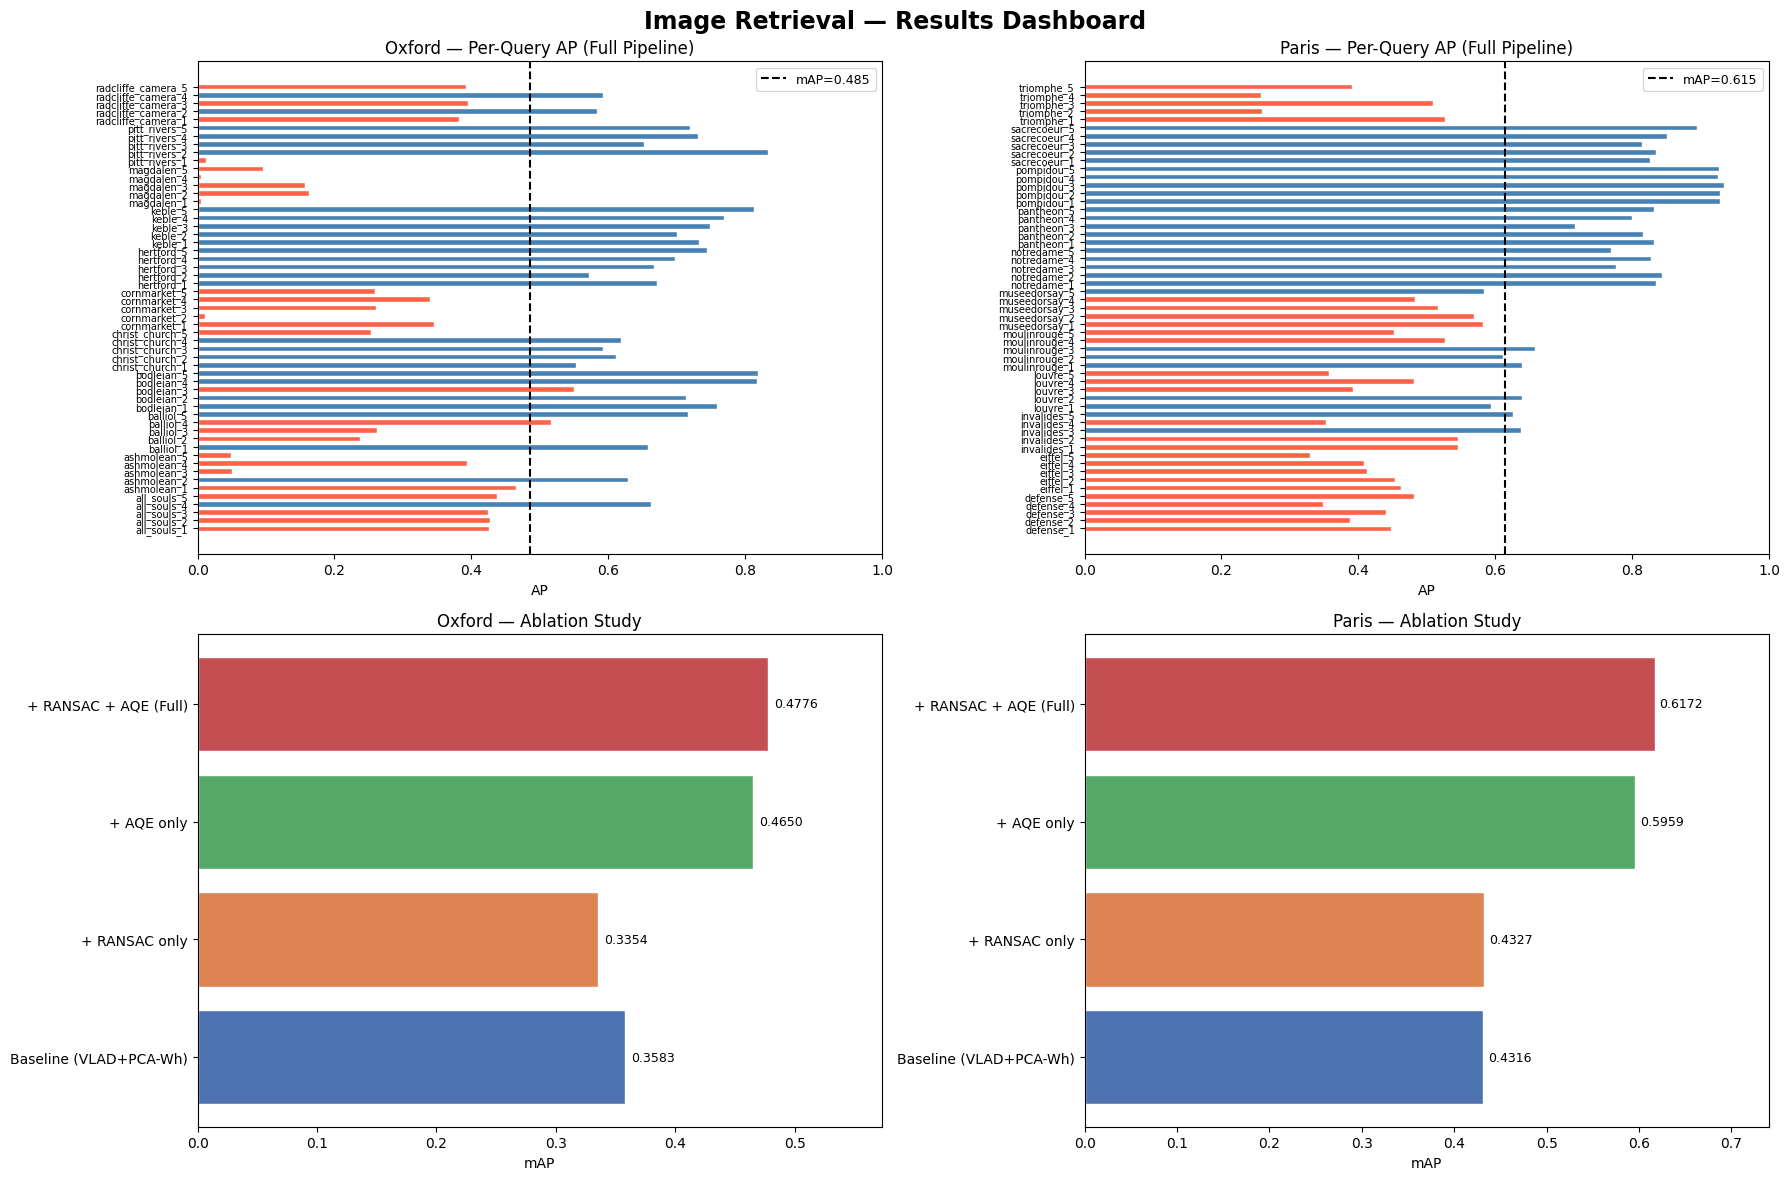

In [20]:
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle('Image Retrieval — Results Dashboard', fontsize=17, fontweight='bold')

# 1. Per-query AP — Oxford
ax = axes[0,0]
if res_ox_f:
    names = [k.replace('oxford_','') for k in res_ox_f]
    aps   = [res_ox_f[k]['ap'] for k in res_ox_f]
    med   = float(np.median(aps))
    ax.barh(range(len(names)), aps,
            color=['steelblue' if a>=med else 'tomato' for a in aps],
            edgecolor='white', height=0.7)
    ax.set_yticks(range(len(names))); ax.set_yticklabels(names, fontsize=7)
    ax.axvline(np.mean(aps), color='k', ls='--', lw=1.5, label=f'mAP={np.mean(aps):.3f}')
    ax.legend(fontsize=9); ax.set_xlabel('AP')
    ax.set_title('Oxford — Per-Query AP (Full Pipeline)'); ax.set_xlim(0,1)

# 2. Per-query AP — Paris
ax = axes[0,1]
if res_pa_f:
    names = [k.replace('paris_','') for k in res_pa_f]
    aps   = [res_pa_f[k]['ap'] for k in res_pa_f]
    med   = float(np.median(aps))
    ax.barh(range(len(names)), aps,
            color=['steelblue' if a>=med else 'tomato' for a in aps],
            edgecolor='white', height=0.7)
    ax.set_yticks(range(len(names))); ax.set_yticklabels(names, fontsize=7)
    ax.axvline(np.mean(aps), color='k', ls='--', lw=1.5, label=f'mAP={np.mean(aps):.3f}')
    ax.legend(fontsize=9); ax.set_xlabel('AP')
    ax.set_title('Paris — Per-Query AP (Full Pipeline)'); ax.set_xlim(0,1)

# 3. Ablation — Oxford
ax = axes[1,0]
if ablation_oxford:
    labs = list(ablation_oxford.keys())
    vals = list(ablation_oxford.values())
    bars = ax.barh(labs, vals, color=['#4C72B0','#DD8452','#55A868','#C44E52'], edgecolor='white')
    for bar, v in zip(bars, vals):
        ax.text(v+0.005, bar.get_y()+bar.get_height()/2, f'{v:.4f}', va='center', fontsize=9)
    ax.set_xlabel('mAP'); ax.set_title('Oxford — Ablation Study')
    ax.set_xlim(0, max(vals)*1.2 if vals else 1)

# 4. Ablation — Paris
ax = axes[1,1]
if ablation_paris:
    labs = list(ablation_paris.keys())
    vals = list(ablation_paris.values())
    bars = ax.barh(labs, vals, color=['#4C72B0','#DD8452','#55A868','#C44E52'], edgecolor='white')
    for bar, v in zip(bars, vals):
        ax.text(v+0.005, bar.get_y()+bar.get_height()/2, f'{v:.4f}', va='center', fontsize=9)
    ax.set_xlabel('mAP'); ax.set_title('Paris — Ablation Study')
    ax.set_xlim(0, max(vals)*1.2 if vals else 1)

plt.tight_layout()
plt.savefig(OUTPUT_DIR/'results_dashboard.png', dpi=120, bbox_inches='tight')
plt.show()

---
# CUANTITATIVE JORDAN

---
# 📋 FINAL SUMMARY

In [ ]:
W = 62
def row(l, v): print(f'║  {l:<30}: {str(v):<{W-36}}║')
print('╔'+'═'*(W-2)+'╗')
print('║'+'  HANDCRAFTED IMAGE RETRIEVAL — SUMMARY'.center(W-2)+'║')
print('╠'+'═'*(W-2)+'╣')
row('Total DB images', N_IMAGES)
row('Oxford queries', len(oxford_queries))
row('Paris  queries', len(paris_queries))
row('K_VLAD', K_VLAD)
row('PCA dim', PCA_DIM)
print('╠'+'═'*(W-2)+'╣')
if oxford_queries:
    row('Oxford baseline mAP', f'{mAP_ox_b:.4f}')
    row('Oxford full     mAP', f'{mAP_ox_f:.4f}  (+{(mAP_ox_f-mAP_ox_b)*100:.1f}%)')
if paris_queries:
    row('Paris  baseline mAP', f'{mAP_pa_b:.4f}')
    row('Paris  full     mAP', f'{mAP_pa_f:.4f}  (+{(mAP_pa_f-mAP_pa_b)*100:.1f}%)')
print('╠'+'═'*(W-2)+'╣')
print('║'+'  ABLATION'.center(W-2)+'║')
print('╠'+'═'*(W-2)+'╣')
print(f'║  {"Component":30}  {"Oxford":>8}  {"Paris":>8}  ║')
print('║'+'-'*(W-2)+'║')
for l in ablation_oxford:
    ox = ablation_oxford.get(l, 0.0)
    pa = ablation_paris.get(l, 0.0)
    print(f'║  {l[:30]:30s}  {ox:8.4f}  {pa:8.4f}  ║')
print('╚'+'═'*(W-2)+'╝')